In [1]:
# Circuit Depth Tutorial Notebook
# =====================================
# This notebook teaches what circuit depth is and how to compute it
# using Qiskit step by step.

# -------------------------------------
# 1. Install dependencies (run once)
# -------------------------------------
# !pip install qiskit

# -------------------------------------
# 2. Import libraries
# -------------------------------------
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer

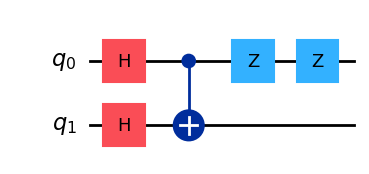

In [10]:
# -------------------------------------
# 3. What is Circuit Depth?
# -------------------------------------
# Circuit depth = the number of sequential layers of gates
# that must be executed one after another.
#
# Gates that act on different qubits at the same time
# can be executed in parallel (same layer).

# -------------------------------------
# 4. Create a simple circuit
# -------------------------------------
qc = QuantumCircuit(2)

qc.h(0)        # Layer 1
qc.h(1)        # Same layer (parallel)
qc.cx(0, 1)    # Layer 2
qc.z(0)        # Layer 3
qc.z(0)  
# qc.draw('text')
qc.draw('mpl')


In [11]:
# -------------------------------------
# 5. Calculate circuit depth
# -------------------------------------
print("Circuit depth:", qc.depth())

Circuit depth: 4


In [4]:
# -------------------------------------
# 6. Understanding depth manually
# -------------------------------------
# Layer breakdown:
# Layer 1: H on q0 and H on q1 (parallel)
# Layer 2: CX gate
# Layer 3: Z gate
# Total depth = 3

In [5]:
# -------------------------------------
# 7. More complex example
# -------------------------------------
qc2 = QuantumCircuit(3)

qc2.h(0)
qc2.h(1)
qc2.h(2)

qc2.cx(0,1)
qc2.cx(1,2)

qc2.z(0)
qc2.x(2)
qc2.draw('mpl')
qc2.draw('text')

print("Circuit depth (qc2):", qc2.depth())

Circuit depth (qc2): 4


In [6]:
# -------------------------------------
# 8. Depth vs Gate Count
# -------------------------------------
# Gate count = total number of gates
# Depth = number of sequential layers

print("Gate count:", qc2.size())

Gate count: 7


In [7]:
# -------------------------------------
# 9. Optimization example
# -------------------------------------
# Sometimes circuits can be rearranged to reduce depth

qc3 = QuantumCircuit(2)
qc3.h(0)
qc3.cx(0,1)
qc3.h(0)
qc3.cx(0,1)

print("Original depth:", qc3.depth())

# Try transpilation optimization
from qiskit import transpile
qc3_opt = transpile(qc3, optimization_level=3)

print("Optimized depth:", qc3_opt.depth())

Original depth: 4
Optimized depth: 1


In [8]:
# -------------------------------------
# 10. Key Takeaways
# -------------------------------------
# - Depth measures time complexity (not gate count)
# - Parallel gates reduce depth
# - Important for NISQ devices (noise accumulates over depth)
# - Lower depth = better performance on real quantum hardware

print("\nDone! You now understand circuit depth.")



Done! You now understand circuit depth.


Depth: 5


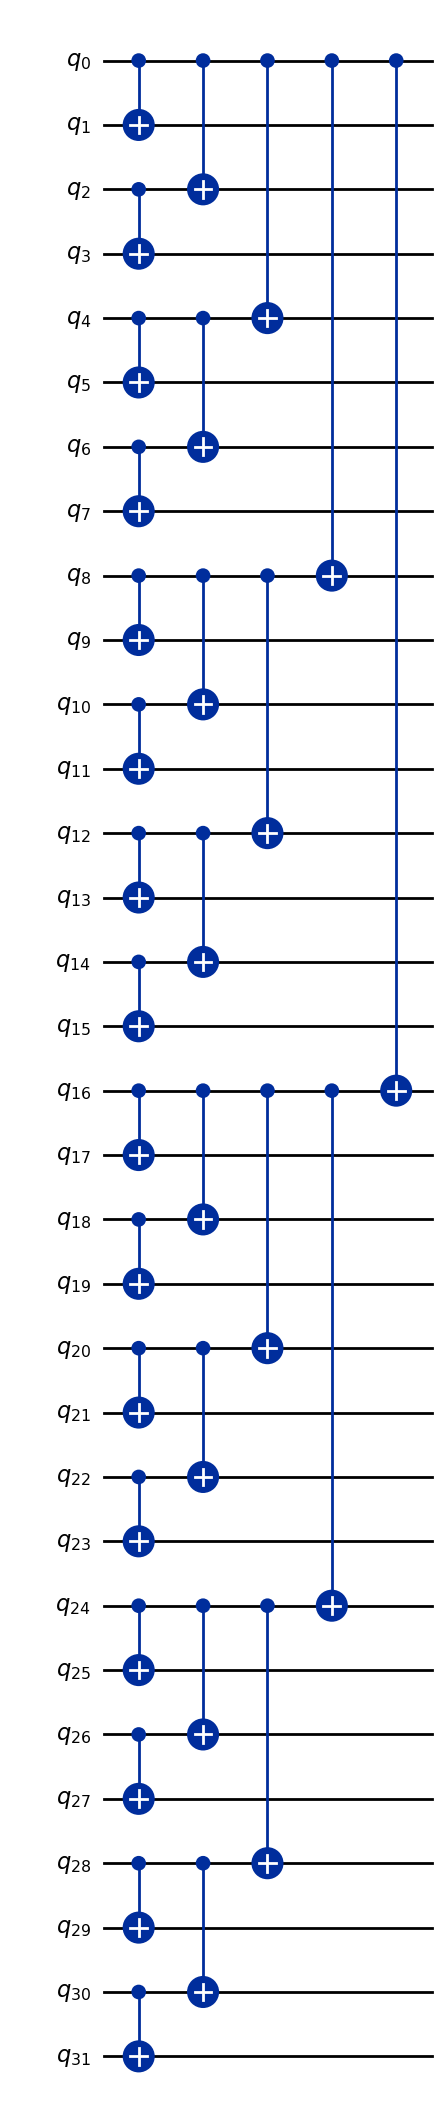

In [12]:
from qiskit import QuantumCircuit
import math

def log_depth_tree(n):
    qc = QuantumCircuit(n)
    
    step = 1
    while step < n:
        for i in range(0, n, 2*step):
            if i + step < n:
                qc.cx(i, i+step)
        step *= 2
    
    return qc

qc = log_depth_tree(32)

print("Depth:", qc.depth())
qc.draw('mpl', fold=-1)